In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Cell 0: Installations and Imports
!pip install pdfplumber textblob

import pdfplumber
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation # Corrected import
from google.colab import files
import warnings

warnings.filterwarnings("ignore")
nltk.download('punkt', quiet=True) # punkt and stopwords downloaded already
nltk.download('stopwords', quiet=True) # punkt and stopwords downloaded already

True

In [ ]:
# Cell 1: Import pdf and read all pages
from google.colab import files

uploaded = files.upload()
pdf_path = list(uploaded.keys())[0]

all_text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            all_text += text + "\n"

print(f"Successfully read {len(pdf.pages)} pages from '{pdf_path}'.")
print(f"Total characters read: {len(all_text):,}")

Saving tcs-annual-report-2024-2025.pdf to tcs-annual-report-2024-2025.pdf
Successfully read 336 pages from 'tcs-annual-report-2024-2025.pdf'.
Total characters read: 1,023,104


In [ ]:
# Cell 2: Save it into a dataframe
df = pd.DataFrame({"raw_text": [all_text]})
print("Text saved into a DataFrame. Here's a preview:")
df.head()

Text saved into a DataFrame. Here's a preview:


,raw_text
0,Integrated\nAnnual\nReport\n2024-25\nIntegrate...


In [ ]:
# Cell 3: Preprocess text
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['raw_text'].apply(preprocess_text)
print("Text has been preprocessed. Here is a sample of the clean text:")
print(df['clean_text'][0][:500])

Text has been preprocessed. Here is a sample of the clean text:
integrated annual report integrated annual report founder jamsetji nusserwanji tata march may free enterprise community another stakeholder business fact purpose existence remembering mr tata padma vibhushan ratan n tata december october profound sense loss bid farewell mr tatas dedication philanthropy mr ratan naval tata truly uncommon leader development society touched lives whose immeasurable contributions shaped millions education healthcare initiatives tata group also fabric left deeprooted


In [ ]:
# Cell 4: Sent Tokenize and calculate sentiment for each sentence
sentences = sent_tokenize(df['raw_text'][0])
sentiments = []

for s in sentences:
    blob = TextBlob(s)
    sentiments.append({
        "sentence": s,
        "polarity": blob.sentiment.polarity,
        "subjectivity": blob.sentiment.subjectivity
    })

df_sentiments = pd.DataFrame(sentiments)
print("Sentiment analysis complete. Here are the results for the first 5 sentences:")
df_sentiments.head()

print("Average polarity:", df_sentiments['polarity'].mean())
print("Average subjectivity:", df_sentiments['subjectivity'].mean())

Sentiment analysis complete. Here are the results for the first 5 sentences:
Average polarity: 0.05093694838145395
Average subjectivity: 0.2460837234825624


In [ ]:
# Cell 5: Word Tokenize the preprocessed text
# Note: This was done as part of the preprocessing in Cell 3.
# This cell just creates the final list of tokens for the next steps.

all_tokens = df['clean_text'][0].split()
print(f"Total number of tokens after preprocessing: {len(all_tokens)}")
print("\nFirst 50 tokens:")
print(all_tokens[:50])

Total number of tokens after preprocessing: 90525

First 50 tokens:
['integrated', 'annual', 'report', 'integrated', 'annual', 'report', 'founder', 'jamsetji', 'nusserwanji', 'tata', 'march', 'may', 'free', 'enterprise', 'community', 'another', 'stakeholder', 'business', 'fact', 'purpose', 'existence', 'remembering', 'mr', 'tata', 'padma', 'vibhushan', 'ratan', 'n', 'tata', 'december', 'october', 'profound', 'sense', 'loss', 'bid', 'farewell', 'mr', 'tatas', 'dedication', 'philanthropy', 'mr', 'ratan', 'naval', 'tata', 'truly', 'uncommon', 'leader', 'development', 'society', 'touched']


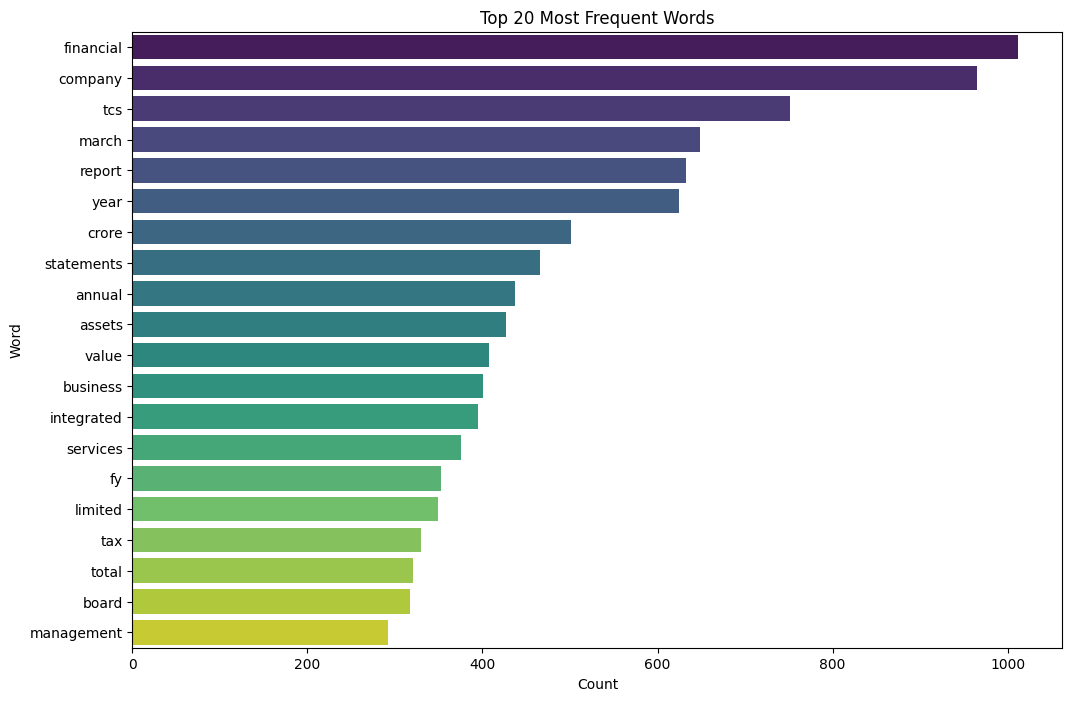

In [ ]:
# Cell 6: Frequent word and Wordcloud
# Calculate and plot frequent words
freq_dist = nltk.FreqDist(all_tokens)
df_freq = pd.DataFrame(freq_dist.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=df_freq, palette='viridis')
plt.title('Top 20 Most Frequent Words')
plt.show()



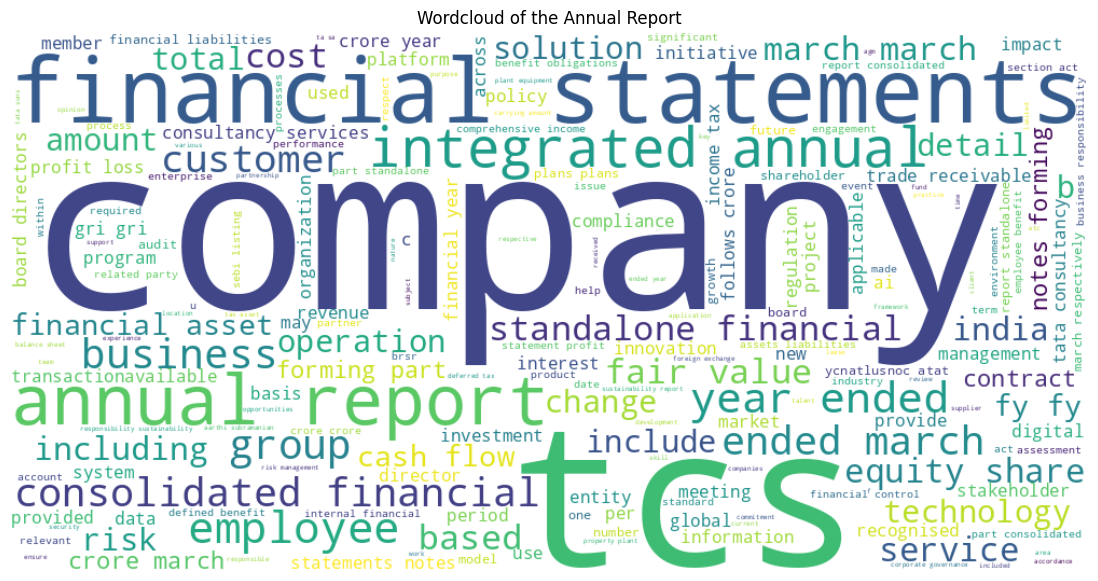

In [ ]:
# Generate and display Wordcloud
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(df['clean_text'][0])

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Wordcloud of the Annual Report')
plt.show()

In [ ]:
# Cell 7: Convert to TF-IDF (Document Term Matrix)
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
doc_term_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])

print("Shape of the TF-IDF Document-Term Matrix (documents, unique words):")
print(doc_term_matrix.shape)

Shape of the TF-IDF Document-Term Matrix (documents, unique words):
(1, 1000)


In [ ]:
# Cell 8: Build Topic Modelling (LDA)
num_topics = 10
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(doc_term_matrix)

feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"--- Top 10 Words for each of the {num_topics} Topics ---")
for topic_idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic #{topic_idx + 1}:")
    print(" ".join([feature_names[i] for i in topic.argsort()[:-11:-1]]))

--- Top 10 Words for each of the 10 Topics ---

Topic #1:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #2:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #3:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #4:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #5:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #6:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #7:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #8:
financial company tcs march report year crore statements annual assets

Topic #9:
good employment designated insurance subsidiary disclosure local locations return billed

Topic #10:
good employment designated insurance subsidiary disclosure 

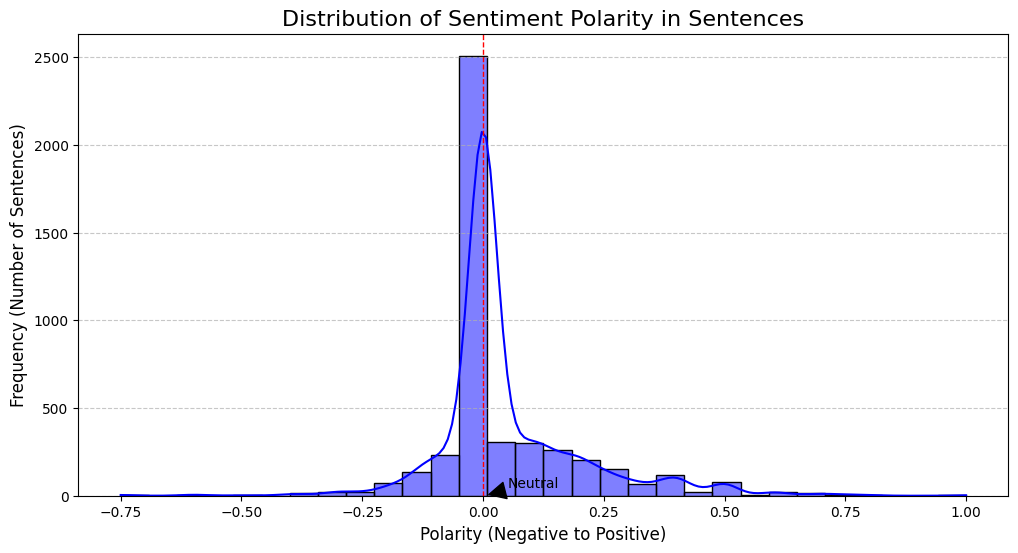

In [ ]:
# Cell 4a: Visualize Sentiment Polarity
plt.figure(figsize=(12, 6))
sns.histplot(df_sentiments['polarity'], bins=30, kde=True, color='blue')
plt.title('Distribution of Sentiment Polarity in Sentences', fontsize=16)
plt.xlabel('Polarity (Negative to Positive)', fontsize=12)
plt.ylabel('Frequency (Number of Sentences)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.annotate('Neutral', xy=(0.01, 5), xytext=(0.05, 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()